# Airfare Analytics — Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the main factors associated with airfare prices across European flights.

The analysis focuses on understanding price distributions and identifying relationships between airfare and flight characteristics, routes, airlines, booking lead time, and temporal factors.

The insights obtained during this stage will guide the subsequent Feature Engineering and Machine Learning stages.

In [40]:
# Import all the libraries neccesaries for this section

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Set the path to the cleandata file
DATA_PATH = Path("../data/processed/airfare_clean.csv")

airfare_df = pd.read_csv(DATA_PATH)

# Display the shape and first 5 rows of the dataframe
airfare_df.shape
airfare_df.head()

#Convert the 'date' column to datetime format
airfare_df['arrival_time'] = pd.to_datetime(airfare_df['arrival_time'])
airfare_df['departure_time'] = pd.to_datetime(airfare_df['departure_time'])
airfare_df['scraped_at'] = pd.to_datetime(airfare_df['scraped_at'])

In [42]:
airfare_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200001 entries, 0 to 200000
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype                    
---  ------                 --------------   -----                    
 0   airline                200001 non-null  str                      
 1   flight                 200001 non-null  str                      
 2   source_city            200001 non-null  str                      
 3   source_country         200001 non-null  str                      
 4   departure_time         200001 non-null  datetime64[us]           
 5   stops                  200001 non-null  int64                    
 6   arrival_time           200001 non-null  datetime64[us]           
 7   destination_city       200001 non-null  str                      
 8   destination_country    200001 non-null  str                      
 9   class                  200001 non-null  str                      
 10  price                  200001 non-null  int

In [43]:
airfare_df[['price']].describe()

,price
count,200001.000000
mean,384.009560
std,395.302427
min,17.000000
25%,189.000000
50%,289.000000
75%,455.000000
max,11614.000000


## 1) Price Distribution

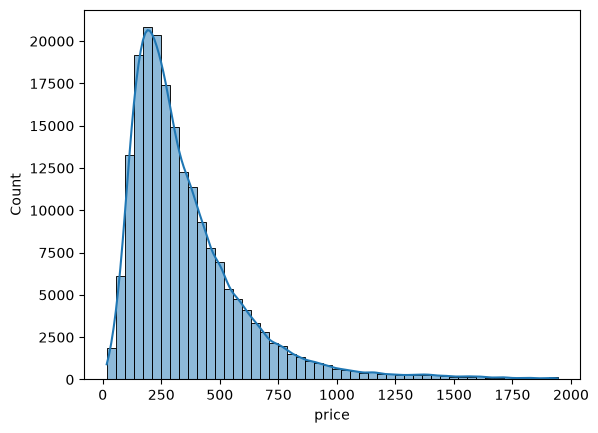

In [105]:
# plot the distribution of the price column using seaborn and the 99th percentile as the upper limit for the x-axis
upper_limit = airfare_df["price"].quantile(0.99)

sns.histplot(
    data=airfare_df[airfare_df["price"] <= upper_limit],
    x="price",
    bins=50,
    kde=True
)

plt.show()

<Axes: xlabel='price'>

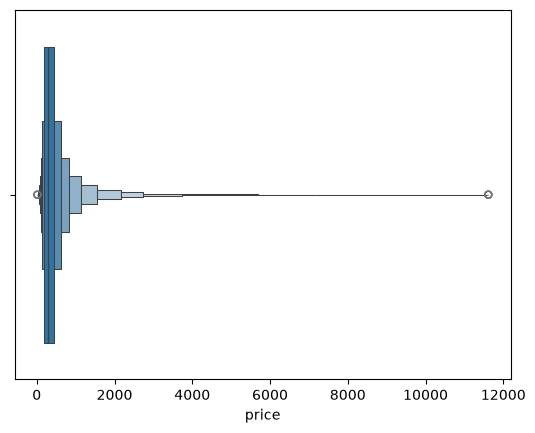

In [106]:
# plot a box plot of the price column using seaborn
sns.boxenplot(data=airfare_df, x="price")

In [107]:
# Calculate quantiles for the price column
airfare_df["price"].quantile([0.75, 0.90, 0.95, 0.99, 0.995, 1])

0.750      455.0
0.900      682.0
0.950      905.0
0.990     1943.0
0.995     2511.0
1.000    11614.0
Name: price, dtype: float64

In [108]:
# Find the maximum price in the price column and display the row with the maximum price
airfare_df["price"].max()
airfare_df.loc[airfare_df["price"].idxmax()]

airline                                                    Aegean + Etihad
flight                                               A3653 / EY188 / EY843
source_city                        Leonardo da Vinci International Airport
source_country                                                       Italy
departure_time                                         2026-06-21 22:20:00
stops                                                                    2
arrival_time                                           2026-06-22 19:05:00
destination_city         Moscow Sheremetyevo Alexander S. Pushkin Inter...
destination_country                                                 Russia
class                                                              economy
price                                                                11614
days_left                                                               51
source_airport                                                         FCO
destination_airport      

In [109]:
airfare_df.nlargest(20, "price")[
    [
        "airline",
        "source_country",
        "destination_country",
        "stops",
        "price",
        "days_left",
        "duration_minutes"
    ]
]

,airline,source_country,destination_country,stops,price,days_left,duration_minutes
123732,Aegean + Etihad,Italy,Russia,2,11614,51,755.0
126210,Aegean + Etihad,Italy,Russia,2,11614,54,755.0
158534,Aegean + Etihad,Italy,Russia,2,11614,36,765.0
195365,Aegean + Etihad,Italy,Russia,2,11614,49,755.0
104980,ITA + Etihad,Italy,Russia,2,11608,50,755.0
111854,ITA + Etihad,Italy,Russia,2,11608,12,860.0
112183,ITA + Etihad,Italy,Russia,2,11608,21,750.0
116447,ITA + Etihad,Italy,Russia,2,11608,9,860.0
123731,ITA + Etihad,Italy,Russia,2,11608,51,755.0
126209,ITA + Etihad,Italy,Russia,2,11608,54,755.0


### Key Findings


- Most flight prices are concentrated in the lower price ranges, with only a small number of very expensive flights.
- Some flights have unusually high prices, but after checking the most expensive observations, they do not seem to be obvious data errors.
- Interestingly, the highest-priced flights are mainly routes to Russia. This could be related to the route itself, the airlines involved, or other flight characteristics, so it will be explored later in the EDA.
- For now, these high-price observations will be kept in the dataset.

## 2) Airlines: How do ticket prices vary across airlines?


In [49]:
from pathlib import Path
import pandas as pd

# Display the number of flights per airline
airfare_df['airline'].value_counts().head(15)

airline
Lufthansa                13736
KLM                      13164
Air France               11881
Vueling                  11598
Iberia                    8749
Scandinavian Airlines     8200
British Airways           6632
SWISS                     5873
ITA                       5252
Eurowings                 5245
Austrian                  5020
Aegean                    4084
Finnair                   3484
Turkish Airlines          3228
Tap Air Portugal          2879
Name: count, dtype: int64

In [50]:
# Calculate the percentage of flights that are operated by multiple airlines
airfare_df["airline"].str.contains(r"\+").mean()

np.float64(0.274598627006865)

Approximately 27.5% of the observations correspond to multi-airline itineraries. To isolate the effect of individual airlines on ticket prices, only flights operated by a single airline are considered in this section. Multi-airline itineraries will still be included in the overall machine learning model.

In [51]:
# Create a summary table of the number of flights, average price, median price, minimum price, and maximum price for each airline and Keep only flights operated by a single airline
single_airline_df = airfare_df[~airfare_df["airline"].str.contains(r"\+")]

# Create airline summary
airline_summary = (single_airline_df.groupby("airline").agg(
        total_flights=("airline", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
    .sort_values(by="total_flights", ascending=False)
)

airline_summary.head(20)

,total_flights,average_price,median_price,min_price,max_price
airline,,,,,
Lufthansa,13736,360.583503,305.0,94,3455
KLM,13164,338.604072,280.5,63,2525
Air France,11881,332.138120,288.0,78,2105
Vueling,11598,190.491119,167.0,17,1350
Iberia,8749,321.463253,260.0,31,1517
Scandinavian Airlines,8200,289.188049,247.0,44,6177
British Airways,6632,413.878920,351.0,72,2908
SWISS,5873,364.910778,301.0,96,3754
ITA,5252,212.696306,176.0,54,1215


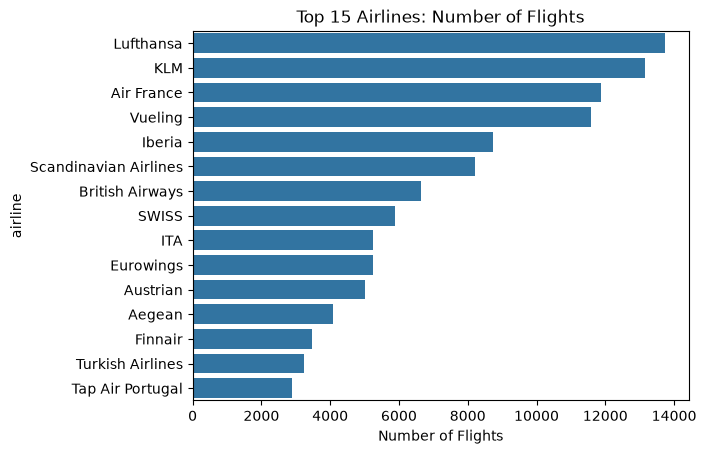

In [52]:
# Create a bar plot of the number of flights vs the median price for each airline
top15_airlines = airline_summary.sort_values("total_flights", ascending=False).head(15)

sns.barplot(
    data=top15_airlines,
    x="total_flights",
    y="airline"
)

plt.title("Top 15 Airlines: Number of Flights")
plt.xlabel("Number of Flights")
plt.show()

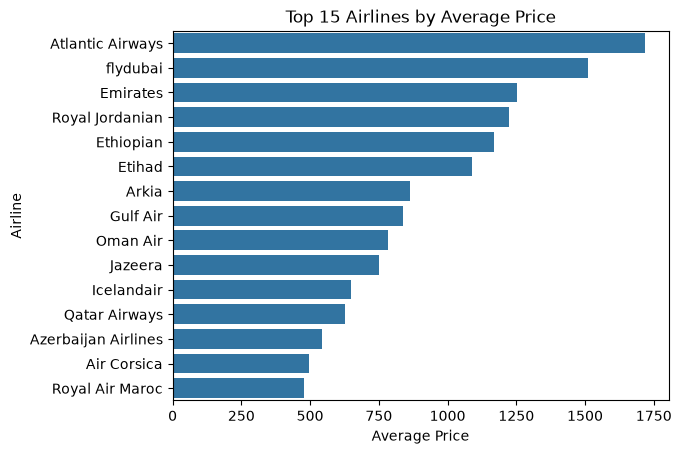

In [53]:
# Select the 15 airlines with the highest average price
top15_expensive_airlines = (airline_summary.sort_values('average_price', ascending=False).head(15))

# Plot

sns.barplot(
    data=top15_expensive_airlines,
    x="average_price",
    y="airline"
)

plt.title("Top 15 Airlines by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Airline")

plt.show()

### Note

This chart shows the average ticket price for each airline, but it does not necessarily mean that one airline is more expensive than another.

Ticket prices depend on several other factors, such as the route, flight duration, number of stops, booking lead time, travel class, and when the price was collected (`scraped_at`).

A fair comparison between airlines would require comparing similar flights, for example, the same route and similar booking conditions.

Therefore, this chart should be interpreted as a general overview of the dataset rather than a direct measure of how expensive each airline is.

### Key Findings

- Lufthansa, KLM and Air France are the most represented single airlines in the dataset.
- Ticket prices vary considerably between airlines. For example, airlines such as easyJet and Vueling show lower typical prices, while British Airways and Turkish Airlines show higher median prices.
- For most airlines, the average price is higher than the median price. This is consistent with the right-skewed price distribution observed earlier, where some expensive flights increase the average.


## 3. Which routes appear most frequently in the dataset?

In [73]:
# Investigate the top 10 routes with the highest number of flights
top_routes = (
    airfare_df
    .groupby(["source_airport", "destination_airport"])
    .size()
    .reset_index(name="total_flights")
    .sort_values("total_flights", ascending=False)
    .head(10)
)

top_routes

,source_airport,destination_airport,total_flights
1500,LPA,ACE,585
989,FRA,MAD,465
643,CPH,ARN,413
1595,MAD,FRA,409
2020,PMI,IBZ,403
185,ARN,CPH,396
1121,HAM,NUE,383
368,BGO,OSL,359
2154,SAW,AYT,357
3,AAL,OSL,350


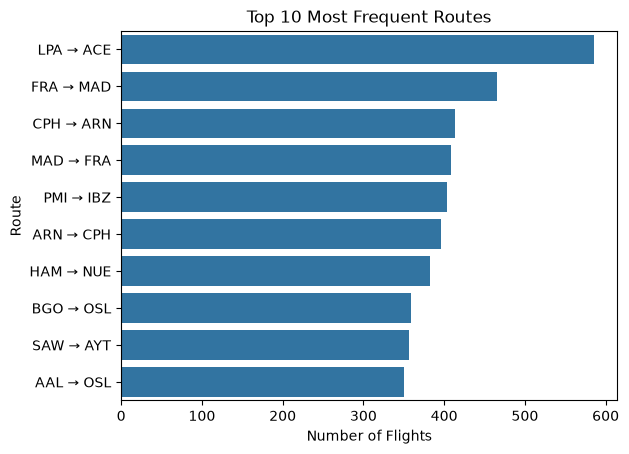

In [74]:
top_routes["route"] = (top_routes["source_airport"] + " → " + top_routes["destination_airport"])


sns.barplot(
    data=top_routes,
    x="total_flights",
    y="route")

plt.title("Top 10 Most Frequent Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

### Key Findings

- The dataset is concentrated around a relatively small number of airport pairs, while most routes appear only a few times.
- Several of the most frequent routes connect major European hubs, suggesting that the dataset mainly captures high-demand connections.
- The most common routes should not be interpreted as the busiest routes in Europe, but rather as the routes most represented in this dataset.

# 4. Which routes have the highest average price?

In [110]:
route_summary = (
    airfare_df
    .groupby(["source_airport", "destination_airport"])
    .agg(
        total_flights=("price", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        max_price=("price", "max"),
        min_price=("price", "min"),
    )
    .reset_index()
) 

route_summary = route_summary[route_summary["total_flights"] >= 30]
route_summary["average_price"] = route_summary["average_price"].round(0)

top_expensive_routes = (route_summary.sort_values("median_price", ascending=False).head(10))

top_expensive_routes



,source_airport,destination_airport,total_flights,average_price,median_price,max_price,min_price
723,DME,BCN,79,2262.0,2514.0,10276,613
781,DUS,DME,55,2285.0,2234.0,6276,827
1547,LTN,TFS,71,2045.0,2233.0,5056,52
1543,LTN,FAO,69,1986.0,2083.0,5110,63
724,DME,DUS,49,1893.0,1851.0,2882,1155
279,AYT,PAD,43,1359.0,1654.0,1882,189
1343,LEJ,FUE,114,1376.0,1457.0,2586,149
1545,LTN,PMI,62,1833.0,1413.0,6374,46
298,BCN,DME,56,1553.0,1412.0,2739,447
2127,RIX,DME,69,1412.0,1391.0,2513,573


### Key Findings

- After filtering routes with a minimum number of observations, several routes involving Moscow (DME) remain among the most expensive in the dataset.
- Some routes show median prices above €2,000, indicating that these are not isolated expensive flights but consistently high-priced routes.
- Even within the same route, there is considerable price variation, as shown by the differences between minimum and maximum prices.
- Route appears to be an important factor in airfare pricing and is likely to explain part of the differences previously observed between airlines.

## 5. For the busiest routes, do ticket prices vary by departure weekday?

In [115]:
# Create a pivot table to calculate the average price per day of the week for each route
avg_per_day = airfare_df.pivot_table(
    index=['source_airport', 'destination_airport'],
    columns='departure_day_of_week',
    values='price',
    aggfunc='median'
).reset_index()

# Merge the top routes with the average price per day of the week in order to analyze the average price for the top routes on each day of the week
top10_weekday = avg_per_day.merge(
    top_routes,
    on=["source_airport", "destination_airport"]
)

top10_weekday 

,source_airport,destination_airport,friday,monday,saturday,sunday,thursday,tuesday,wednesday,total_flights,route
0,AAL,OSL,248.0,315.0,385.0,366.0,267.0,315.0,269.0,350,AAL → OSL
1,ARN,CPH,293.0,239.0,232.0,296.0,353.0,299.0,353.0,396,ARN → CPH
2,BGO,OSL,124.0,138.0,271.5,167.5,138.0,144.5,124.0,359,BGO → OSL
3,CPH,ARN,181.0,369.0,220.0,181.0,215.0,220.0,220.0,413,CPH → ARN
4,FRA,MAD,434.0,324.0,441.0,338.5,370.5,253.0,294.0,465,FRA → MAD
5,HAM,NUE,420.0,366.5,469.5,410.0,419.0,392.5,403.5,383,HAM → NUE
6,LPA,ACE,128.0,128.0,128.0,128.0,128.0,128.0,128.0,585,LPA → ACE
7,MAD,FRA,259.0,374.0,253.0,374.0,210.0,241.0,247.0,409,MAD → FRA
8,PMI,IBZ,145.0,136.0,136.0,136.0,136.0,136.0,136.0,403,PMI → IBZ
9,SAW,AYT,107.0,101.0,99.0,88.0,96.5,84.0,77.0,357,SAW → AYT


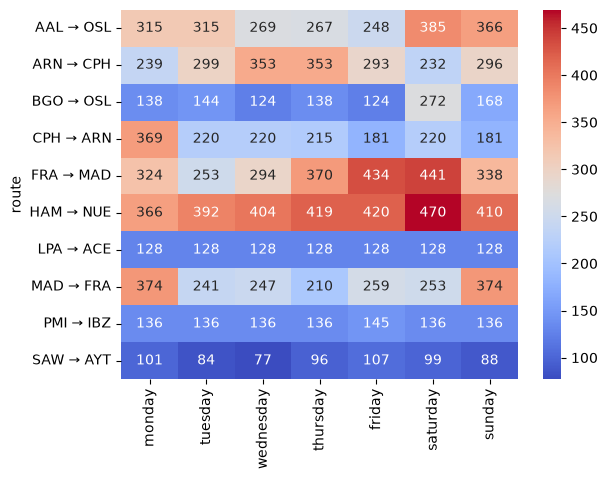

In [116]:
# Create a heatmap to visualize the average price per day of the week for the top 10 routes with the highest number of flights
days = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday']

heat_data = top10_weekday.set_index('route')[days].astype(float)

sns.heatmap(heat_data, cmap='coolwarm', annot=True, fmt=".0f")


plt.show()

## Key Findings
Most of the busiest routes tend to have higher median ticket prices on Fridays and Saturdays.
However, this pattern is not consistent across every route. Some routes, such as PMI → IBZ and LPA → ACE, show almost no price variation throughout the week.
For several routes, Wednesday and Thursday appear to be the least expensive days to travel.
These results suggest that the day of the week influences prices, but its effect depends on the specific route. It should not be considered a universal rule.

## 6. How does the booking lead time affect ticket prices?

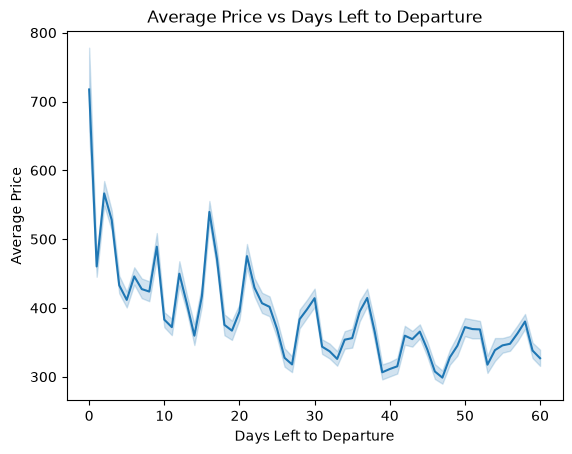

In [114]:
# Create a line plot to visualize the relationship between average price and days left to departure
sns.lineplot(x='days_left', y='price', data=airfare_df)

plt.title("Average Price vs Days Left to Departure")
plt.xlabel("Days Left to Departure")
plt.ylabel("Average Price")

plt.show()

### Key Findings

- Ticket prices are highest when flights are booked close to the departure date.
- Prices generally decrease as the booking lead time increases, although the relationship is not perfectly linear.
- The largest price difference occurs within the first few days before departure, suggesting that last-minute bookings are considerably more expensive.
- Price variability is also greater for last-minute bookings, indicating that fares become less predictable closer to departure.

## 7. Does time of day influence ticket prices?

<Axes: xlabel='price', ylabel='departure_daypart'>

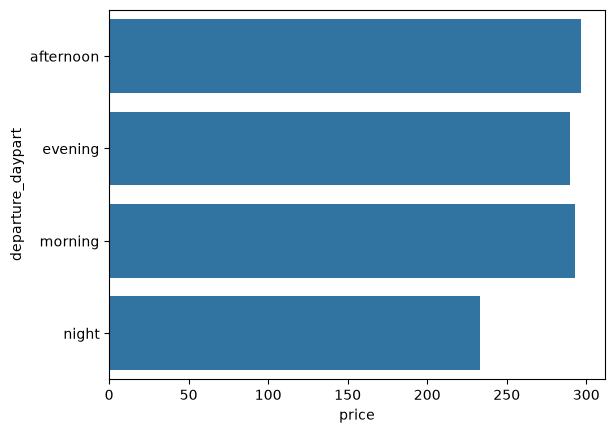

In [129]:
# Create a  table to calculate the average price per daypart of the day for each route

daypart_summary = airfare_df.groupby(['departure_daypart']).agg({'price': 'median'})


sns.barplot(data=daypart_summary, x='price', y='departure_daypart')

<Axes: xlabel='price', ylabel='departure_daypart'>

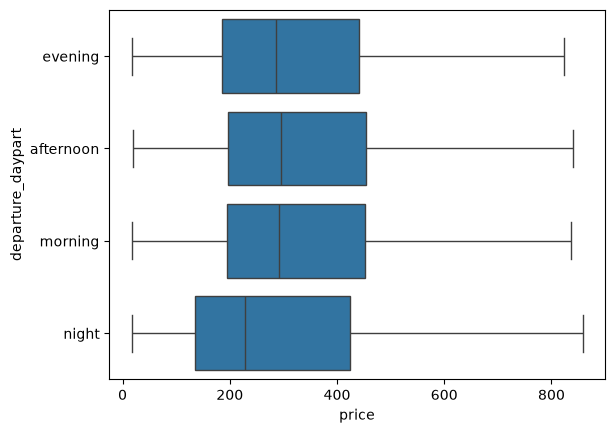

In [133]:
# Create a box plot to visualize the distribution of prices for each daypart of the day
sns.boxplot(data=airfare_df[airfare_df["price"] <= upper_limit], x='price', y='departure_daypart', showfliers=False)

## Key Findings
- Flights departing at night tend to have the lowest median ticket prices.
- Morning, afternoon and evening departures show very similar price distributions.
- Although departure time appears to influence ticket prices, its effect is relatively small compared with other variables analyzed previously, such as booking lead time or flight route.